# Hotel Booking Cancellation Prediction
## Comparing Logistic Regression and SVM

## Load Importance Packages and Data

In [1]:
# load packages
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# sckit-learn packages
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve, auc

# models
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier

In [2]:
# load data
hotel_bookings = pd.read_csv('/Users/kiepeeh1/Documents/00 Working Projects/Hotel Data Analytics/Hotel Analytics/Data/Processed_Data/final_hotel_bookings.csv')

## Features Engineering

- Transform the target variable `is_canceled` into category variable.
- Ensure all categorical variables are classified correctly per column type. 
- Select features(variables) for building models

In [3]:
hotel_bookings['is_canceled'] = hotel_bookings['is_canceled'].astype('category') 
   
# convert all Dtype == 'object' columns to categorical type
for col in hotel_bookings.select_dtypes(include='object').columns:
    hotel_bookings[col] = hotel_bookings[col].astype('category')

In [4]:
# split the data into features and target variable
feature_cols = [
    'lead_time', 'market_segment', 'distribution_channel', 'customer_type',
    'stays_in_week_nights', 'stays_in_weekend_nights', 'adr', 'hotel',
    'deposit_type', 'arrival_date_month', 'arrival_date_week_number', 'adults'
]

#X = pd.get_dummies(hotel_bookings[feature_cols], drop_first=False)
num_cols = ['lead_time', 'stays_in_week_nights', 'stays_in_weekend_nights', 'adr', 'arrival_date_week_number', 'adults']
cat_cols = [c for c in feature_cols if c not in num_cols]

X = hotel_bookings[feature_cols]
y = hotel_bookings['is_canceled']


## Model Training

- Split full bookings data into `training` and `testing` sets.
- Preprocess data to ensure categorical variables are converted to One Hot Encoder and numerical variables to scale values. 
- Fit two models (`Logistic Regression` and `Support Vector Machine`) using `training data`.
- Predict classes using the `testing data`.
- While fitting, document the time taken to fit each model.

In [5]:
# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, stratify=y, random_state=19)
print(f"Training set size: {round(len(X_train)/len(X)*100)}% \n\
Testing set size: {round(len(X_test)/len(X)*100)}%")

# Preprocessing pipeline for numerical and categorical features
preprocessor = ColumnTransformer([
    ('num', StandardScaler(), num_cols),
    ('cat', OneHotEncoder(handle_unknown='ignore'), cat_cols)
])

Training set size: 70% 
Testing set size: 30%


### Building Models

In [6]:
from sklearn.calibration import CalibratedClassifierCV
import time
import warnings

In [7]:
warnings.filterwarnings("ignore")
# Fitting models 
logistic_reg = LogisticRegression(max_iter=5000)

logistic_reg = Pipeline([
    ('preprocess', preprocessor),
    ('model', logistic_reg)
])

svm = CalibratedClassifierCV(SVC(), ensemble=False, method='sigmoid', cv=3)
svm = Pipeline([
    ('preprocess', preprocessor),
    ('model', svm)
])


# Training models
start_time_1 = time.time()
logistic_reg.fit(X_train, y_train)
log_time = time.time() - start_time_1

start_time_2 = time.time()
svm.fit(X_train, y_train)
svm_time = time.time() - start_time_2

# Precdictions
logistic_reg_pred = logistic_reg.predict(X_test)
svm_pred = svm.predict(X_test)

# Print runtime results
print(f"Logistic Regression: {log_time:.2f} seconds")
print(f"Support Vector Machine: {svm_time:.2f} seconds")

Logistic Regression: 0.11 seconds
Support Vector Machine: 177.77 seconds


## Model Evaluation

In [8]:
model_preds = {
    "Logistic Regression": logistic_reg_pred,
    "Support Vector Machine": svm_pred,
}

for model, preds in model_preds.items():
    print(f"{model} Results:\n{classification_report(y_test, preds)}\n")

Logistic Regression Results:
              precision    recall  f1-score   support

           0       0.76      0.96      0.85     19011
           1       0.64      0.18      0.28      7208

    accuracy                           0.75     26219
   macro avg       0.70      0.57      0.56     26219
weighted avg       0.72      0.75      0.69     26219


Support Vector Machine Results:
              precision    recall  f1-score   support

           0       0.76      0.97      0.85     19011
           1       0.68      0.17      0.28      7208

    accuracy                           0.75     26219
   macro avg       0.72      0.57      0.56     26219
weighted avg       0.73      0.75      0.69     26219




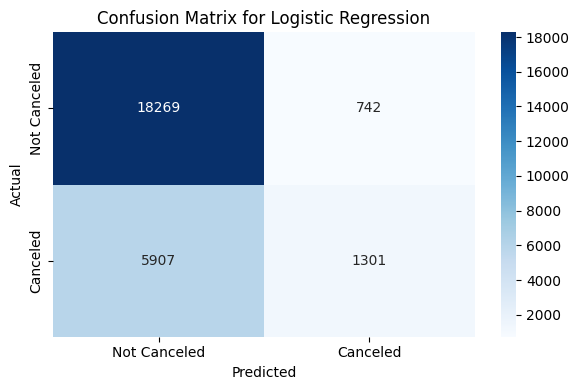

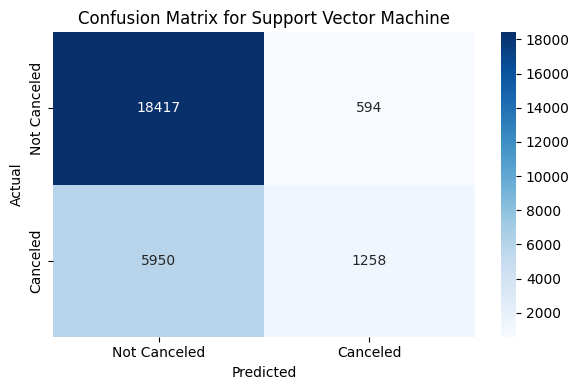

In [ ]:
# Confusion Matrix for each model
for model, preds in model_preds.items():
    cm = confusion_matrix(y_test, preds)
    plt.figure(figsize=(6, 4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Not Canceled', 'Canceled'], 
    yticklabels=['Not Canceled', 'Canceled'])
    plt.title(f'Confusion Matrix for {model}')
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.tight_layout()

### ROC AUC 

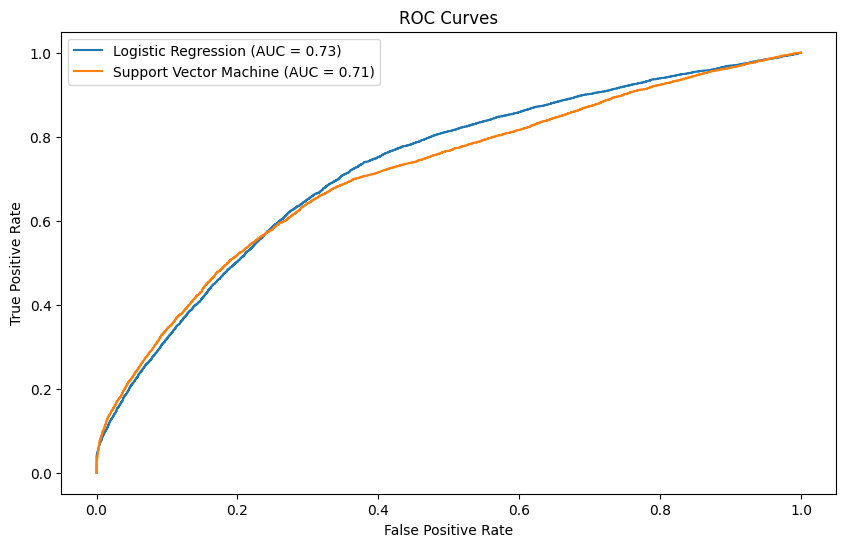

In [12]:
# plot ROC curves for each model
plt.figure(figsize=(10, 6))
for model, preds in model_preds.items():
    if model == "Logistic Regression":
        y_proba = logistic_reg.predict_proba(X_test)[:, 1]
    elif model == "Support Vector Machine":
        y_proba = svm.predict_proba(X_test)[:, 1]

    fpr, tpr, _ = roc_curve(y_test, y_proba)
    auc_score = roc_auc_score(y_test, y_proba)
    plt.plot(fpr, tpr, label=f'{model} (AUC = {auc_score:.2f})')

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves')
plt.legend()
plt.show()

### Feature Importance

Top 10 Features With Positive Impact


,feature,coefficient,odds_ratio
26,deposit_type_Non Refund,2.380289,10.808028
21,customer_type_Transient,0.525768,1.691758
0,lead_time,0.410683,1.507847
12,market_segment_Online TA,0.347512,1.415542
6,market_segment_Aviation,0.328813,1.389318
30,arrival_date_month_December,0.288262,1.334107
18,distribution_channel_Undefined,0.255734,1.291409
3,adr,0.228877,1.257187
13,market_segment_Undefined,0.175046,1.191301
17,distribution_channel_TA/TO,0.156618,1.169549


Top 10 Features With Negative Impact


,feature,coefficient,odds_ratio
25,deposit_type_No Deposit,-1.533365,0.215808
27,deposit_type_Refundable,-0.935916,0.392227
11,market_segment_Offline TA/TO,-0.765862,0.464933
22,customer_type_Transient-Party,-0.269870,0.763479
15,distribution_channel_Direct,-0.262901,0.768818
20,customer_type_Group,-0.255619,0.774437
9,market_segment_Direct,-0.234732,0.790782
14,distribution_channel_Corporate,-0.195502,0.822422
24,hotel_Resort Hotel,-0.155018,0.856399
39,arrival_date_month_September,-0.119214,0.887618


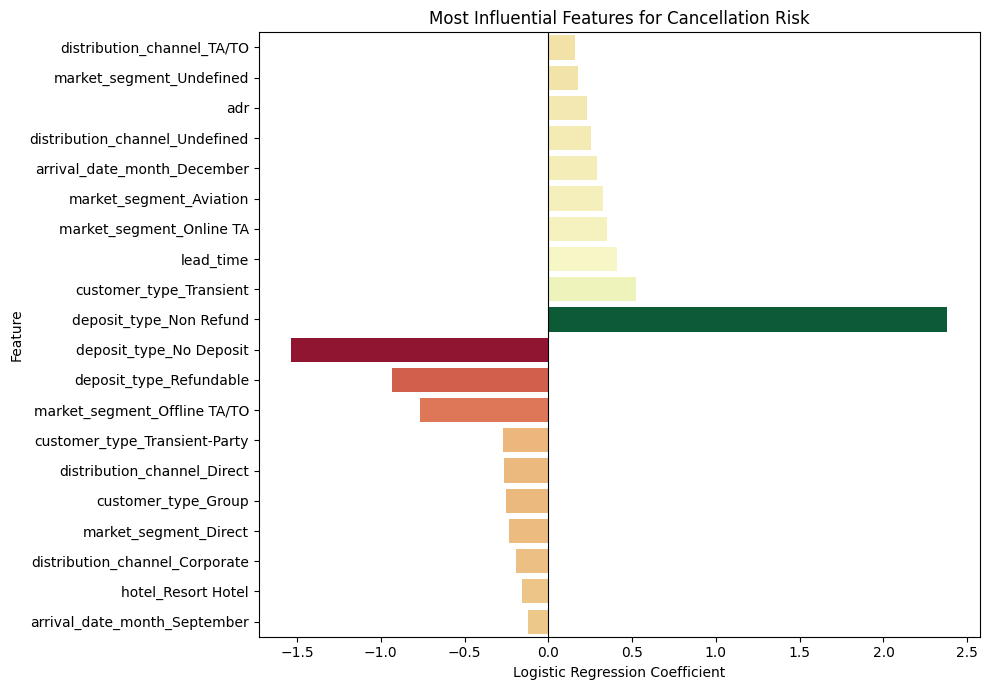

In [37]:
import numpy as np

coef_values = logistic_reg.named_steps['model'].coef_[0]
preprocess = logistic_reg.named_steps['preprocess']
cat_features = list(preprocess.named_transformers_['cat'].get_feature_names_out(cat_cols))
feature_names = num_cols + cat_features

features_importance_df = pd.DataFrame({
    'feature': feature_names,
    'coefficient': coef_values
}).sort_values('coefficient', ascending=False)

top_positive = features_importance_df.nlargest(10, 'coefficient').copy()
top_negative = features_importance_df.nsmallest(10, 'coefficient').copy()

# Odds ratios show the multiplicative change in cancellation odds
top_positive['odds_ratio'] = top_positive['coefficient'].apply(np.exp)
top_negative['odds_ratio'] = top_negative['coefficient'].apply(lambda x: np.exp(x))

print("Top 10 Features With Positive Impact")
display(top_positive)

print("Top 10 Features With Negative Impact")
display(top_negative)

# Plot the strongest positive and negative coefficients
top_features = pd.concat([
    top_positive.sort_values('coefficient'),
    top_negative.sort_values('coefficient')
])

plt.figure(figsize=(10, 7))
sns.barplot(
    data=top_features,
    x='coefficient',
    y='feature',
    hue='coefficient',
    palette='RdYlGn',
    legend=False
)
plt.axvline(0, color='black', linewidth=0.8)
plt.title('Most Influential Features for Cancellation Risk')
plt.xlabel('Logistic Regression Coefficient')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()

In [ ]:
# Plot importance of features for Logistic Regression
preproc = logistic_reg.named_steps['preprocess']
num_features = num_cols
ohe = preproc.named_transformers_['cat']
cat_features = list(ohe.get_feature_names_out(cat_cols))
feature_names = num_features + cat_features
coeffs = logistic_reg.named_steps['model'].coef_[0]

features_importance_df = pd.DataFrame({
    'feature': feature_names,
    'coefficient': coeffs
}).sort_values('coefficient', ascending=False)
features_importance_df.head(10)

#feature_importance = pd.DataFrame({
    #'Feature': X.columns,
    #'Importance': logistic_reg.named_steps['model'].coef_[0]
#}).sort_values(by='Importance', ascending=False)
#feature_importance.head(10)

#feature_importance = pd.DataFrame({
    #'Feature': X.columns,
    #'Importance': logistic_reg.named_steps['model'].coef_[0]
#}).sort_values(by='Importance', ascending=False)
#feature_importance.head(10)

# plot the top 10 features
plt.figure(figsize=(10, 6))
sns.barplot(x='coefficient', y='feature', data=features_importance_df.head(10))
plt.title('Top 10 Features by Coefficient (Logistic Regression)')
plt.xlabel('Coefficient Value')
plt.ylabel('Feature') 
plt.show()

## Analyzing Results
- Extract probabilites associated with each predicted booking class - Canceled or Not Canceled. 
- Append it to the testing set and combined probabilites for each model into a single dataset.
- Add the associated revenue exposure risk associated with each booking by create a variable `proba_loss`.

In [ ]:
# Decision tree probabilities + prediction df
#dt_proba = pd.DataFrame(
    #decision_tree.predict_proba(X_test),
    #columns=['dt_pred_0', 'dt_pred_1'],
    #index=X_test.index
#)
#prediction_dt = X_test.copy()
#prediction_dt['actual'] = y_test
#prediction_dt['predicted'] = decision_tree_pred
#prediction_dt = prediction_dt.join(dt_proba)

# SVM: ensure it supports predict_proba (re-fit with probability=True if necessary), then build df
#if not hasattr(svm, "predict_proba"):
    #svm = SVC(probability=True)
    #svm.fit(X_train, y_train)
    #svm_pred = svm.predict(X_test)

In [ ]:
# Logistic regression probabilities + prediction df
logreg_proba = pd.DataFrame(
    logistic_reg.predict_proba(X_test),
    columns=['logreg_pred_0', 'logreg_pred_1'],
    index=X_test.index
)
prediction_logreg = X_test.copy()
prediction_logreg['actual'] = y_test
prediction_logreg['predicted'] = logistic_reg_pred
prediction_logreg = prediction_logreg.join(logreg_proba)

svm_proba = pd.DataFrame(
    svm.predict_proba(X_test),
    columns=['svm_pred_0', 'svm_pred_1'],
    index=X_test.index
)
prediction_svm = X_test.copy()
prediction_svm['actual'] = y_test
prediction_svm['predicted'] = svm_pred
prediction_svm = prediction_svm.join(svm_proba)

# merge the prediction dataframes for comparison
predictions_combined = prediction_logreg.merge(
    prediction_svm[['svm_pred_0', 'svm_pred_1', 'predicted']],
    left_index=True, right_index=True, suffixes=('_logreg', '_svm')
)

In [15]:
predictions_combined.head(10)

,lead_time,market_segment,distribution_channel,customer_type,stays_in_week_nights,stays_in_weekend_nights,adr,hotel,deposit_type,arrival_date_month,arrival_date_week_number,actual,predicted_logreg,logreg_pred_0,logreg_pred_1,svm_pred_0,svm_pred_1,predicted_svm
80726,1,Offline TA/TO,Corporate,Transient,1,0,110.50,City Hotel,No Deposit,May,19,0,0,0.926127,0.073873,0.769580,0.230420,0
79399,143,Offline TA/TO,TA/TO,Transient,1,1,89.10,City Hotel,No Deposit,April,15,0,0,0.798420,0.201580,0.777772,0.222228,0
36414,204,Offline TA/TO,TA/TO,Transient-Party,2,2,72.75,City Hotel,No Deposit,October,41,0,0,0.885735,0.114265,0.774166,0.225834,0
76834,2,Direct,Direct,Transient,1,0,143.00,City Hotel,No Deposit,March,9,0,0,0.863735,0.136265,0.771021,0.228979,0
79613,54,Direct,Direct,Transient,4,2,111.00,City Hotel,No Deposit,April,15,0,0,0.802938,0.197062,0.777900,0.222100,0
59730,33,Online TA,TA/TO,Transient,2,2,154.80,City Hotel,No Deposit,March,13,0,0,0.627700,0.372300,0.756425,0.243575,0
56790,150,Online TA,TA/TO,Transient-Party,3,1,89.67,City Hotel,No Deposit,March,13,1,0,0.734152,0.265848,0.814283,0.185717,0
74183,105,Online TA,TA/TO,Transient,1,1,95.37,City Hotel,No Deposit,December,53,0,0,0.587553,0.412447,0.621764,0.378236,0
59865,56,Offline TA/TO,TA/TO,Transient,3,1,103.28,City Hotel,No Deposit,March,14,0,0,0.848836,0.151164,0.772288,0.227712,0
55709,5,Corporate,Corporate,Transient,1,0,74.00,City Hotel,No Deposit,December,49,0,0,0.845642,0.154358,0.771128,0.228872,0


In [ ]:
# calculate expected revenue per booking: ADR * (stays_in_week_nights + stays_in_weekend_nights)
predictions_combined['expected_revenue'] = predictions_combined['adr']* (predictions_combined['stays_in_week_nights'] + predictions_combined['stays_in_weekend_nights'])

# calcuate expected loss per booking for each model: predicted probability of cancellation * expected revenue
predictions_combined['logreg_Loss'] = predictions_combined['logreg_pred_1'] * predictions_combined['expected_revenue']
predictions_combined['svm_Loss'] = predictions_combined['svm_pred_1'] * predictions_combined['expected_revenue']

# calcuate the difference in expected loss between the two models
predictions_combined['pred_Loss_diff'] = predictions_combined['logreg_Loss'] - predictions_combined['svm_Loss']

In [ ]:
predictions_combined[['actual', 'predicted_logreg', 'predicted_svm', 'logreg_pred_1', 'svm_pred_1', 'expected_revenue', 'logreg_Loss', 'svm_Loss', 'pred_Loss_diff']].head(10)

,actual,predicted_logreg,predicted_svm,logreg_pred_1,svm_pred_1,expected_revenue,logreg_Loss,svm_Loss,pred_Loss_diff
80726,0,0,0,0.073873,0.230420,110.50,8.163018,25.461371,-17.298354
79399,0,0,0,0.201580,0.222228,178.20,35.921483,39.600977,-3.679495
36414,0,0,0,0.114265,0.225834,291.00,33.251177,65.717828,-32.466651
76834,0,0,0,0.136265,0.228979,143.00,19.485870,32.743931,-13.258061
79613,0,0,0,0.197062,0.222100,666.00,131.243192,147.918313,-16.675121
59730,0,0,0,0.372300,0.243575,619.20,230.528103,150.821413,79.706689
56790,1,0,0,0.265848,0.185717,358.68,95.354276,66.613021,28.741255
74183,0,0,0,0.412447,0.378236,190.74,78.670115,72.144814,6.525301
59865,0,0,0,0.151164,0.227712,413.12,62.449070,94.072210,-31.623139
55709,0,0,0,0.154358,0.228872,74.00,11.422472,16.936533,-5.514061


In [ ]:
# save the predictions_combined dataframe to a CSV file
predictions_combined.to_csv('/Users/kiepeeh1/Documents/00 Working Projects/Hotel Data Analytics/Hotel Analytics/Data/Processed_Data/predictions_combined.csv', index=False)

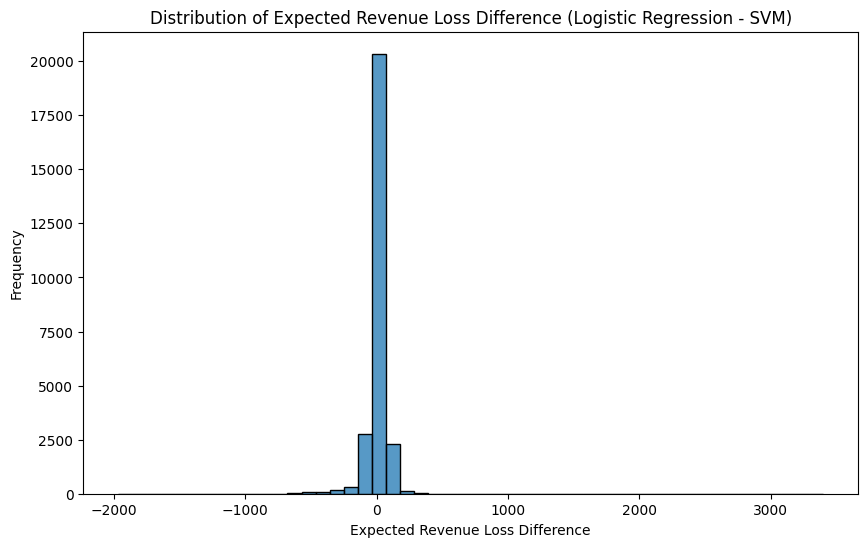

In [ ]:
# distribution of expected revenue loss difference between the two models (less than 400)
plt.figure(figsize=(10, 6))
sns.histplot(data = predictions_combined[predictions_combined['adr'] < 1000], 
x = predictions_combined['pred_Loss_diff'], bins=50)
plt.title('Distribution of Expected Revenue Loss Difference (Logistic Regression - SVM)')
plt.xlabel('Expected Revenue Loss Difference')
plt.ylabel('Frequency')
plt.show()

# Summary (Results)
- 

# Enhance Model Performance

In [16]:
# drop market segment == 'complementary' from the dataset
hotel_bookings_copy2 = hotel_bookings[hotel_bookings['market_segment'] != 'Complementary']
# Drop bookings greater than 1000 in data-- turns out only 1 booking has adr > 1000 (actual 5400), so we can drop it to avoid skewing the data
hotel_bookings_copy2 = hotel_bookings_copy2[hotel_bookings_copy2['adr'] < 1000] 
# drop adr < 0
hotel_bookings_copy2 = hotel_bookings_copy2[hotel_bookings_copy2['adr'] >= 0]

In [21]:
# new dataset after dropping complementary market segment and bookings with adr > 1000
print(hotel_bookings_copy2.info())
print(hotel_bookings_copy2[['adr', 'revenue', 'stays_in_week_nights', 'stays_in_weekend_nights', 'adults', 'lead_time']].describe())

<class 'pandas.core.frame.DataFrame'>
Index: 86692 entries, 0 to 87395
Data columns (total 37 columns):
 #   Column                     Non-Null Count  Dtype   
---  ------                     --------------  -----   
 0   hotel                      86692 non-null  category
 1   arrival_date               86692 non-null  category
 2   is_canceled                86692 non-null  category
 3   lead_time                  86692 non-null  int64   
 4   arrival_date_year          86692 non-null  int64   
 5   arrival_date_month         86692 non-null  category
 6   arrival_date_week_number   86692 non-null  int64   
 7   arrival_date_day_of_month  86692 non-null  int64   
 8   stays_in_weekend_nights    86692 non-null  int64   
 9   stays_in_week_nights       86692 non-null  int64   
 10  adults                     86692 non-null  int64   
 11  meal                       86692 non-null  category
 12  country                    86244 non-null  category
 13  market_segment             86692 non

In [28]:
hotel_bookings_copy2['family_flag'] = hotel_bookings['family_flag'].astype('category') 

New_Features_Cols = ['total_of_special_requests', 'adults', 'family_flag',
    'lead_time', 'market_segment', 'distribution_channel', 'customer_type',
    'stays_in_week_nights', 'stays_in_weekend_nights', 'adr', 'hotel',
    'deposit_type', 'arrival_date_month', 'arrival_date_week_number'
]

new_num_cols = ['total_of_special_requests', 'adults', 'lead_time', 'stays_in_week_nights', 'stays_in_weekend_nights', 'adr', 'arrival_date_week_number']
new_cat_cols = [c for c in New_Features_Cols if c not in new_num_cols]

X = hotel_bookings_copy2[New_Features_Cols]
y = hotel_bookings_copy2['is_canceled']

In [29]:
print(X.info())
print(X.head(10))

<class 'pandas.core.frame.DataFrame'>
Index: 86692 entries, 0 to 87395
Data columns (total 14 columns):
 #   Column                     Non-Null Count  Dtype   
---  ------                     --------------  -----   
 0   total_of_special_requests  86692 non-null  int64   
 1   adults                     86692 non-null  int64   
 2   family_flag                86692 non-null  category
 3   lead_time                  86692 non-null  int64   
 4   market_segment             86692 non-null  category
 5   distribution_channel       86692 non-null  category
 6   customer_type              86692 non-null  category
 7   stays_in_week_nights       86692 non-null  int64   
 8   stays_in_weekend_nights    86692 non-null  int64   
 9   adr                        86692 non-null  float64 
 10  hotel                      86692 non-null  category
 11  deposit_type               86692 non-null  category
 12  arrival_date_month         86692 non-null  category
 13  arrival_date_week_number   86692 non

In [31]:
# split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, stratify=y, random_state=19)

preprocessor = ColumnTransformer([
    ('num', StandardScaler(), new_num_cols),
    ('cat', OneHotEncoder(handle_unknown='ignore'), new_cat_cols)
])

In [35]:
logistic_reg_2 = LogisticRegression(max_iter=5000)
logistic_reg_2 = Pipeline([
    ('preprocess', preprocessor),
    ('model', logistic_reg_2)
])

svm_2 = CalibratedClassifierCV(SVC(), ensemble=False, method='sigmoid', cv=5)
svm_2 = Pipeline([
    ('preprocess', preprocessor),
    ('model', svm_2)
])


# Training models
logistic_reg_2.fit(X_train, y_train)
svm_2.fit(X_train, y_train)

# Precdictions
logistic_reg_pred = logistic_reg_2.predict(X_test)
svm_pred = svm_2.predict(X_test)

/Users/kiepeeh1/Library/Python/3.9/lib/python/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: divide by zero encountered in matmul
  raw_prediction = X @ weights + intercept
/Users/kiepeeh1/Library/Python/3.9/lib/python/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: overflow encountered in matmul
  raw_prediction = X @ weights + intercept
/Users/kiepeeh1/Library/Python/3.9/lib/python/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: invalid value encountered in matmul
  raw_prediction = X @ weights + intercept
/Users/kiepeeh1/Library/Python/3.9/lib/python/site-packages/sklearn/linear_model/_linear_loss.py:330: RuntimeWarning: divide by zero encountered in matmul
  grad[:n_features] = X.T @ grad_pointwise + l2_reg_strength * weights
/Users/kiepeeh1/Library/Python/3.9/lib/python/site-packages/sklearn/linear_model/_linear_loss.py:330: RuntimeWarning: overflow encountered in matmul
  grad[:n_features] = X.T @ grad_point

In [36]:
model_preds_new = {
    "Logistic Regression": logistic_reg_pred,
    "Support Vector Machine": svm_pred,
    #"Decision Tree": decision_tree_pred
}

for model, preds in model_preds_new.items():
    print(f"{model} Results:\n{classification_report(y_test, preds)}\n")

Logistic Regression Results:
              precision    recall  f1-score   support

           0       0.78      0.94      0.86     18827
           1       0.68      0.32      0.43      7181

    accuracy                           0.77     26008
   macro avg       0.73      0.63      0.64     26008
weighted avg       0.76      0.77      0.74     26008


Support Vector Machine Results:
              precision    recall  f1-score   support

           0       0.80      0.93      0.86     18827
           1       0.69      0.38      0.49      7181

    accuracy                           0.78     26008
   macro avg       0.74      0.66      0.67     26008
weighted avg       0.77      0.78      0.76     26008




In [39]:
# confusion matrix
cnf_matrix_log_reg2 = confusion_matrix(y_test, logistic_reg_pred)
cnf_matrix_log_reg_df = pd.DataFrame(cnf_matrix_log_reg2, index = ['Not Canceled', 'Canceled'], 
columns = ['Predicted Not Canceled', 'Predicted Canceled'])

cnf_matrix_svm2 = confusion_matrix(y_test, svm_pred)
cnf_matrix_svm_df = pd.DataFrame(cnf_matrix_svm2, index = ['Not Canceled', 'Canceled'], 
columns = ['Predicted Not Canceled', 'Predicted Canceled'])

print(f"Logistic Regression Confusion Matrix:\n{cnf_matrix_log_reg_df}\n")
print(f"Support Vector Machine Confusion Matrix:\n{cnf_matrix_svm_df}\n")

Logistic Regression Confusion Matrix:
              Predicted Not Canceled  Predicted Canceled
Not Canceled                   17764                1063
Canceled                        4903                2278

Support Vector Machine Confusion Matrix:
              Predicted Not Canceled  Predicted Canceled
Not Canceled                   17591                1236
Canceled                        4457                2724



# Results
Clearly strong improvement in recall of canceled bookings (17% --> 32%) while maintaining 93% recall for completed bookings.